#Introduction

Hello viewers, this is Harsh Deshmukh my University Id no is ***GH1039479***. Today we are going to look at a NLP pipe line created to predict Real and fake news. It's an classification task, and I will try different Machine learning as well as Deep learning models.

##Understanding Business problem

In the digital age, misinformation spreads faster than ever. Businesses, governments, and media houses face the growing challenge of identifying and controlling the spread of fake news to maintain trust, security, and transparency. To combat this challenge, I have found a robust dataset crafted for the development and evaluation of machine learning models that can distinguish between real and fake news.

#Objectives

The objective of this project is simple, classify the real and fake news with help of ML or DL model. But if we want to achieve our goal we must create an pipe line that can first take textual data as input clean and process it, tokenize it and finally with the help of the model predict the news type.  Then the model can be integrated into content moderation systems or browser extensions for fact-checking This was an simple explanation to a complex process. Well to get more in detail we must follow the sections below.     

##Import all required libraries.

In [ ]:
!pip install emoji

In [ ]:
import os
import shutil
import pandas as pd
import string
import re
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

Downloading required packages

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#Data collection

###Link to the dataset on kaggle https://www.kaggle.com/datasets/razanaqvi14/real-and-fake-news

For this project I will use kaggle API to get the dataset, as it will be more easy to implement the model on any sever. plus it bypasses the need to download the data in my machine.    
The API will give us 2 datasets Fake.csv and True.csv

The file contains 23,481 fabricated or misleading news and 21,417 real news articles sourced from reliable outlets.  

Each data set consists of 4 columns originally   
title: Headline used in the article

text: Main content of the article

subject: Thematic label of the article (e.g.,conspiracy, political bias)

date: Assigned or published date

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harshdeshmukh1928","key":"2d020989c78c9f0ddedbfe8b1ce8bb80"}'}

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d razanaqvi14/real-and-fake-news

Dataset URL: https://www.kaggle.com/datasets/razanaqvi14/real-and-fake-news
License(s): CC-BY-NC-SA-4.0
real-and-fake-news.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip real-and-fake-news.zip

Archive:  real-and-fake-news.zip
replace Fake.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace True.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


##Data Preparation
This are the 2 main datasets we got from the API

In [ ]:
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

let's merge the datasets togather. I will create a new column "lablel" to identify whether news is fake or true.

In [ ]:
df_true["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)

In [ ]:
df.sample(10)

,title,text,subject,date,label
17474,Syria demands pullout of Turkish troops from c...,AMMAN (Reuters) - Syria demanded on Saturday t...,worldnews,"October 14, 2017",1
21007,All the president's men: China's politburo lin...,BEIJING (Reuters) - President Xi Jinping of Ch...,worldnews,"September 4, 2017",1
13138,Philippines' Duterte orders police to provide ...,MANILA (Reuters) - Philippine President Rodrig...,worldnews,"December 5, 2017",1
42423,THE BEST ANTI-HILLARY AD EVER MADE…You’ll Want...,The Ted Cruz campaign has identified the enemy...,left-news,"Feb 12, 2016",0
20025,U.N. seeks 'massive' help for Rohingya fleeing...,DHAKA/YANGON (Reuters) - The United Nations ap...,worldnews,"September 14, 2017",1
810,"Trump, Abe didn't discuss bilateral FTA: Japan...",TOKYO (Reuters) - U.S. President Donald Trump ...,politicsNews,"November 6, 2017",1
288,Senate votes to pursue tax bill negotiations w...,WASHINGTON (Reuters) - U.S. Senate Republicans...,politicsNews,"December 6, 2017",1
34450,MULTI-MILLIONAIRE #NFL PLAYERS Take Knee Durin...,Does anyone else find it ironic that black mul...,politics,"Sep 12, 2016",0
30492,POLITICS FIRST: LEFTIST PARENTS Of Former Comb...,The heartbreaking story of two parents who put...,politics,15-Feb-18,0
29825,Why Mike Bloomberg Running For President Will...,While having a third independent option for pr...,News,"January 31, 2016",0


Let's marge the 2 columns title and text together  to column named as content.

In [ ]:
df["content"] = df["title"] + " " + df["text"]

droping all unnesesary columns

In [ ]:
df = df.drop(['subject', 'date', "title", "text"], axis=1)

let us see whats in the final version of df

In [ ]:
df.sample(7)

,label,content
15337,1,Cuban opposition falls at first hurdle as Cast...
41983,0,SINS OF SOCIALISM…Doctors Pumping Air Into Inf...
2112,1,Romania negotiating to buy U.S. rocket systems...
30877,0,WATCH: MITT ROMNEY DOESN’T Think Roy Moore Des...
26412,0,FBI Warns Republicans: Do Not Leak Clinton Em...
25303,0,Couple Married 37 Years In Disagreement On El...
10855,1,House panel approves plan to privatize air tra...


In [ ]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


In [ ]:
df.isnull().sum()

,0
label,0
content,0


#Text cleaning and EDA

So, we have our data ready now let's clean it and understand what we have got.

In [ ]:
def check_for_urls_and_emojis(text):
    url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*(),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
    has_url = bool(url_pattern.search(text))
    has_emoji = any(char in emoji.EMOJI_DATA for char in text)
    return has_url, has_emoji

df['has_url'], df['has_emoji'] = zip(*df['content'].apply(check_for_urls_and_emojis))

print("Number of rows with URLs:", df['has_url'].sum())
print("Number of rows with emojis:", df['has_emoji'].sum())

Number of rows with URLs: 3299
Number of rows with emojis: 3


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
  text = text.lower()
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = emoji.replace_emoji(text, replace='')
  text = re.sub(r'http\S+|www\.\S+', '', text)

  words = nltk.word_tokenize(text)
  words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and word.isalpha()]
  return " ".join(words)

In [ ]:
df['clean_text'] = df['content'].apply(clean_text)

In [ ]:
df = df[['label', 'content', 'clean_text']]

By creating clean_text() we got some idea of what's in our data. to handle this, I cleaned the text with some libraires like re, string and emoji.  Additionally every textual data needs to be cleaned with few steps for model to understand it.

a. Lowercasing: Converted all text to lowercase to reduce vocabulary redundancy.

b. Punctuation Removal: Removed commas, periods, quotation marks, and other non-alphabetic characters.

c. Stopword Removal: Common English stopwords removed to reduce noise.

d. Tokenization: Split the text into sequences of words using Keras Tokenizer.

e. lemmatization:  Serving a purpose akin to stemming, lemmatization seeks to distill words to their foundational forms.

Now that we have got our clean_text we can divide it into real_text and fake_text to plot word cloud.  While word cloud doesn't sever an direct purpose in model training or testing, but it will give us an idea about our data. which can be used in other methods to analyze and interpret textual data

In [ ]:
real_text = " ".join(df[df["label"] == 1]["clean_text"])
fake_text = " ".join(df[df["label"] == 0]["clean_text"])

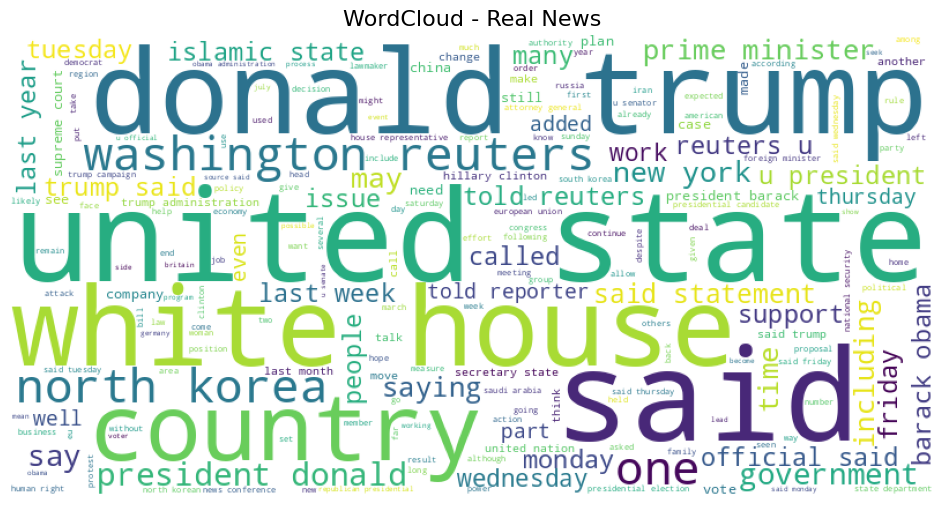

In [ ]:
plt.figure(figsize=(12,6))
plt.title("WordCloud - Real News", fontsize=16)
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(real_text))
plt.axis("off")
plt.show()

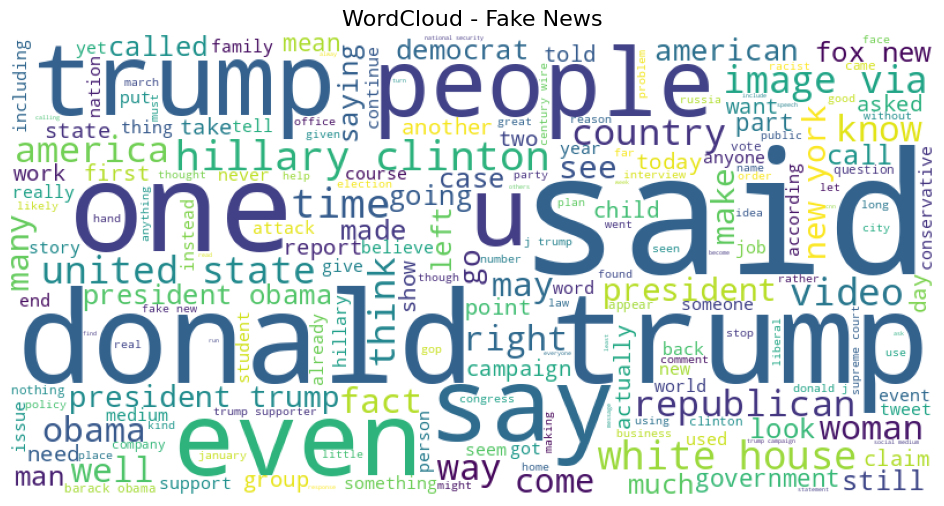

In [ ]:
plt.figure(figsize=(12,6))
plt.title("WordCloud - Fake News", fontsize=16)
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(fake_text))
plt.axis("off")
plt.show()

To get more insights from the data, let's see whether the news length plays any role in its authenticity.  

In [ ]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

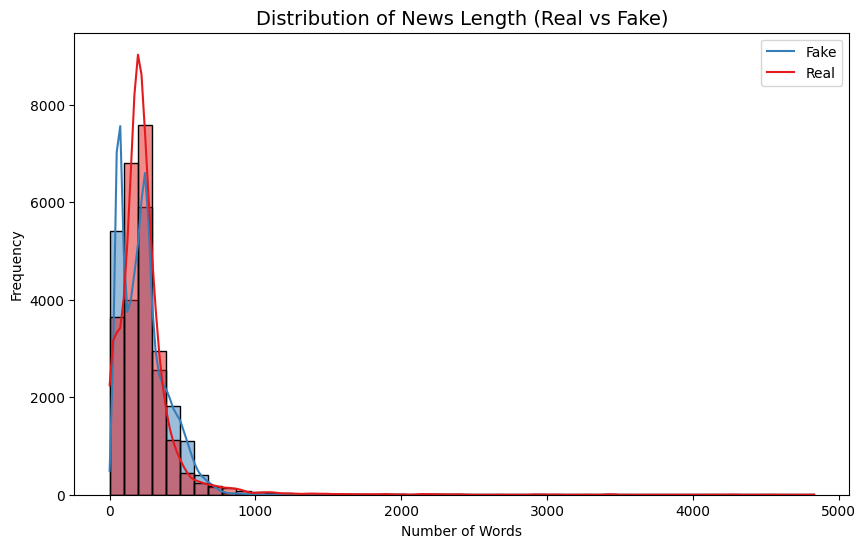

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True, palette="Set1")
plt.title("Distribution of News Length (Real vs Fake)", fontsize=14)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend(["Fake", "Real"])
plt.show()

#Feature Extraction

We need some feature extraction techniques to convert our text into a matrix(or vector) of features. For this project I will be using TF-IDF.

##TF-IDF Vectorizer

I have set max_features=5000, ngram_range=(1,2) and then fitted clean_text column.


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df["clean_text"])
y = df["label"]
print("TF-IDF shape:", X.shape)

TF-IDF shape: (44898, 5000)


##Train Test Split
One of the most important step in Machine learning is to have separate datasets for Training and Testing.  Here I have spited data into 80% training  and 20% for testing, the random state is set to 1918.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1928)

# The model Training

As we now we are working on classification task so first I will use classification Machine learning models and then Deep learning model.

After doing some research, I have found 4 best models for classification tasks.

Logistic Regression

Naive Bayes

Random Forest

SVM

I have trained and tested all of the models and noted the Accuracy scores for each of them. So, for the final version of this project I will be just demonstrate the best model based on the Accuracy score.

Here's the Final model random Forest. I have set n_estimators to 100 and random_state to 42.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

##Accuracy

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.9977728285077951


Accuracy scores of all the models used,

* Logistic Regression - 0.989532

* Naive Bayes - 0.940423

* Random Forest - 0.997772

* SVM - 0.995100

##Confusion Matrix

Confusion matrix is a simple table used to measure how well a classification model is performing. It compares the predictions made by the model with the actual results and shows where the model was right or wrong. This helps you understand where the model is making mistakes so you can improve it

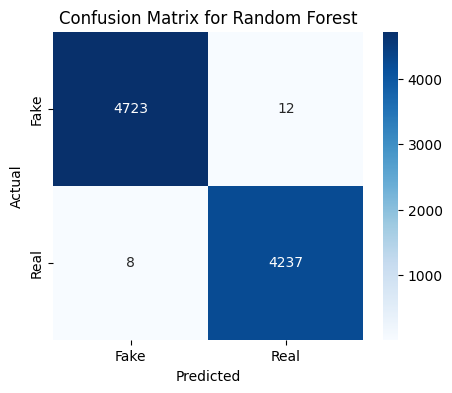

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---

Now that we have completed ML, let's jump to the DL. I will be using LSTM for this task because it is a type of recurrent neural network (RNN) capable of learning long-term dependencies in sequence data, making it highly suitable for language modeling and text classification.

#Deep Learning Model name LSTM

First let's prepare our text for deep learning

In [ ]:
MAX_VOCAB = 10000
MAX_LEN = 300

Tokenizing the text

In [ ]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

Converting text to sequences

In [ ]:
sequences = tokenizer.texts_to_sequences(df["clean_text"])

Padding the text so that sequence will be of same length.

In [ ]:
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

In [ ]:
labels = df["label"].values

As we have changed the data by converting it into sequence and adding padding, we have to Train test split it again. I will keep same ratio as before.  

In [ ]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=1928)

##Defining the LSTM Model

In [ ]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##Let's Train the Model now

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=75,
    batch_size=256,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8291 - loss: 0.4065 - val_accuracy: 0.9179 - val_loss: 0.3392
Epoch 2/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7986 - loss: 0.4462 - val_accuracy: 0.5815 - val_loss: 0.6699
Epoch 3/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.5832 - loss: 0.6588 - val_accuracy: 0.9350 - val_loss: 0.2376
Epoch 4/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9128 - loss: 0.2813 - val_accuracy: 0.9133 - val_loss: 0.1878
Epoch 5/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9438 - loss: 0.1857 - val_accuracy: 0.9745 - val_loss: 0.0728
Epoch 6/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9779 - loss: 0.0731 - val_accuracy: 0.9783 - val_loss: 0.0762
Epoch 7/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9857 - loss: 0.0547 - val_accuracy: 0.9893 - val_loss: 0.0341
Epoch 8/75
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9758 - loss: 0.0773 - val_

##Visualizing Accuracy

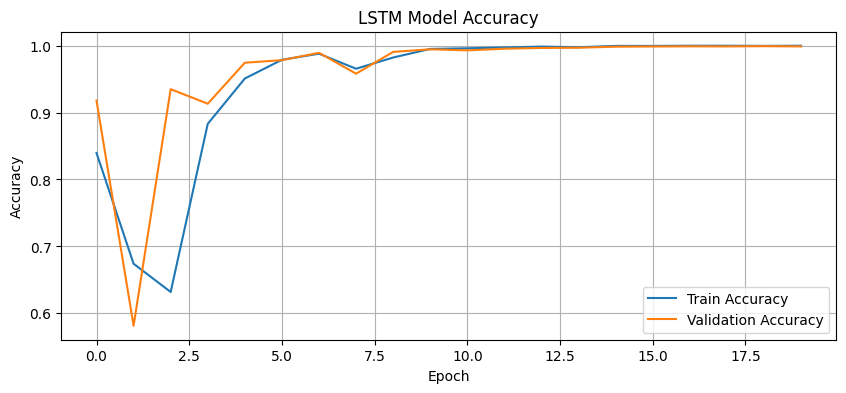

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Let's use a different method to see the final accuracy by testing on actual test dataset.

In [ ]:
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9987 - loss: 0.0062

Final Test Accuracy: 0.9990


---

#Predicting on New Inputs

Well we have trained our model and tested it one test set that we created in the beginning. Now let's test our model on real world data. For that I have got 10 news 5 real and 5 fake. in order predict it on our model we will first need them to be cleaned and tokenized as we did for the training set.  

In [ ]:
def predict_news(text, model, tokenizer, max_len=300):

    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    def clean_input(t):
      t = text.lower()
      t = text.translate(str.maketrans('', '', string.punctuation))
      t = emoji.replace_emoji(text, replace='')
      t = re.sub(r'http\S+|www\.\S+', '', text)

      words = nltk.word_tokenize(text)
      words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and word.isalpha()]
      return " ".join(words)

    cleaned = clean_input(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    prob = model.predict(padded)[0][0]
    label = "REAL" if prob > 0.5 else "FAKE"
    confidence = prob if prob > 0.5 else 1 - prob

    print(f" Text: {text}")
    print(f" Prediction: {label} ({confidence:.2f} confidence)")

After creating a small predict_news() we will get our cleaned real world news. let's pass text through our model.

#Real world Examples

In [ ]:
examples = [
    "The German government has increased the national minimum wage to €12.41 per hour starting July 2025, aiming to help workers cope with rising living costs. Labor unions supported the move, while small businesses have expressed concerns about potential impacts.",
"NASA’s Europa Clipper mission is scheduled to launch in October 2024 and will investigate the potential for life on Jupiter’s moon Europa. The spacecraft will perform flybys to analyze the moon’s icy surface and subsurface ocean.",
"The United Nations reports that June 2025 was the hottest June ever recorded globally, citing rising greenhouse gas emissions and El Niño conditions. Scientists warn that urgent global action is needed to prevent further temperature increases.",
"The Government of India has rolled out a digital health card initiative that allows citizens to store and access their medical records online. This is part of a broader plan to modernize the healthcare system under the Ayushman Bharat Digital Mission.",
"Berlin will host the International AI Summit in September 2025, bringing together tech experts, researchers, and policymakers from around the world. The summit will focus on ethical AI, innovation, and global cooperation in artificial intelligence development.",
"Researchers in Australia claim to have found dolphins that can understand over 200 English words and respond with specific vocal patterns. The discovery allegedly occurred near a popular tourist beach, but the scientific community has not verified the findings.",
"The German Finance Ministry announced a plan to replace the Euro with a national cryptocurrency called 'CryptoMark' by 2026. Officials claim this will eliminate cash and reduce fraud, though no official EU statement has confirmed the decision.",
"NASA reportedly detected a radio signal from the Proxima Centauri system that scientists believe may be from intelligent alien life. The signal supposedly repeats mathematical sequences not found in nature, though NASA has not released an official report.",
"Coca-Cola has launched a new drink that claims to help consumers burn fat while sitting by using a secret blend of enzymes. The company says the formula was tested on elite athletes, but no peer-reviewed studies have confirmed its effects.",
"Google has allegedly developed an AI system that can read human thoughts using brain wave scans. Reports suggest the technology can identify emotions and words without speech, but privacy advocates have raised ethical concerns about its use."
]

for i, example in enumerate(examples, 1):
    print(f"\n Example {i}")
    predict_news(example, model, tokenizer)


 Example 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
 Text: The German government has increased the national minimum wage to €12.41 per hour starting July 2025, aiming to help workers cope with rising living costs. Labor unions supported the move, while small businesses have expressed concerns about potential impacts.
 Prediction: REAL (0.51 confidence)

 Example 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
 Text: NASA’s Europa Clipper mission is scheduled to launch in October 2024 and will investigate the potential for life on Jupiter’s moon Europa. The spacecraft will perform flybys to analyze the moon’s icy surface and subsurface ocean.
 Prediction: FAKE (1.00 confidence)

 Example 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
 Text: The United Nations reports that June 2025 was the hottest June ever recorded globally, citing rising greenhouse gas emissions and El Niño conditions. Scientists warn that urgent global action is needed to prevent further temperature increases.
 Prediction: FAKE (1.0

Above are the predictions of the real world data.

---

#Accuracy Comparison

Now is the time to compare our two best models Random Forest and  LSTM. To get an better understanding of their performance, I have created an graph that will accuracy of both the models.

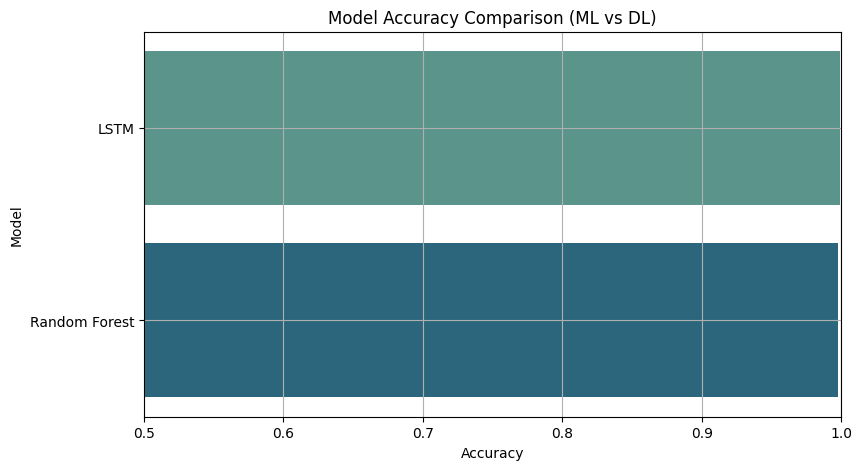

In [ ]:
accuracy_data = {'Model': ['Random Forest', 'LSTM'], 'Accuracy': [acc, accuracy]}
acc_df = pd.DataFrame(accuracy_data)
acc_df_sorted = acc_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x="Accuracy", y="Model", data=acc_df_sorted, palette="crest")
plt.title("Model Accuracy Comparison (ML vs DL)")
plt.xlim(0.5, 1.00)
plt.grid(True)
plt.show()

#Project Summary

We implemented and evaluated two categories of models:

* Traditional Machine Learning Model: Random Forest Classifier using TF-IDF features.

* Deep Learning Model: LSTM (Long Short-Term Memory) network using tokenized and padded sequences.

Both models were trained on a labeled dataset containing real and fake news articles. The preprocessing pipeline included text cleaning, exploratory data analysis (EDA), and vectorization suitable for each model type.

The Random Forest model provided a fast and interpretable baseline, while the LSTM demonstrated superior accuracy by leveraging sequential patterns in the text. The models were evaluated using accuracy.

To conclude I will say that…

Fake news detection is a growing concern for media companies, social networks, governments, and fact-checking organizations. Manual detection is inefficient when we work on big data sets, and fake news spreads rapidly. The solution that I will suggest is, to use model like above for detecting fake news. while both ML and DL models have got high accuracy score one can chose any one of the models for real world deployment depending on the use case, resource availability and project budget.


# Refrence

Dataset - https://www.kaggle.com/datasets/razanaqvi14/real-and-fake-news

Business context and conceptual thinking - https://openai.com/index/chatgpt/

nltk - https://www.nltk.org/_modules/nltk.html

re - https://docs.python.org/3/library/re.html

string - https://docs.python.org/3/library/string.html

emoji - https://pypi.org/project/emoji/

sklearn - https://scikit-learn.org/

tensorflow - https://www.tensorflow.org/api_docs

ML and DL concepts - https://www.geeksforgeeks.org/


---

#***THANK YOU...***